---
date: "2026-04-24"
date-modified: last-modified
format:
  html:
    toc: true
---


# Branching Processes

## 1. Concept and Definition

A **branching process** is a mathematical model used to describe the evolution of a population over time. It relies on a few core assumptions:

* The system begins with a single initial individual (Generation 0).
* In each discrete time step (or generation), every living individual produces a random number of offspring based on a fixed probability distribution.
* Every individual behaves entirely **independently** of all other individuals.
* The offspring rules remain exactly the same across all generations.

One of the most important questions we can ask about a branching process is: **What is the probability of eventual extinction?** (i.e., the probability that the population size eventually hits zero and remains there forever).

---

## 2. Example: The Amoeba Population

**Problem Statement:**
Consider a single amoeba living in a pond. Every minute, the amoeba undergoes a transition. With equal probability ($1/3$ each), it will either:
1. Die without reproducing ($0$ offspring).
2. Remain exactly one amoeba ($1$ offspring).
3. Split into two distinct amoebas ($2$ offspring).

In all subsequent minutes, every living amoeba will behave according to these exact same rules, independently of the others. What is the probability that this amoeba population will eventually die out completely?

---

## 3. Mathematical Solution (First-Step Analysis)

Let $D$ be the event that the population *eventually* dies out. We want to find $P(D)$.

Because this problem is perfectly self-similar (an offspring amoeba starts a completely identical, independent sub-population), we can use **First-Step Analysis**. We proceed by conditioning on the outcome of the very first minute using the [Law of Total Probability](law-of-total-probability.ipynb). 

Let $B_i$ be the event that the initial amoeba turns into exactly $i$ amoebas in the first step (for $i = 0, 1, 2$).
$$P(D) = P(D|B_0)P(B_0) + P(D|B_1)P(B_1) + P(D|B_2)P(B_2)$$

Let's evaluate the conditional probabilities logically:

* **$P(D|B_0)$**: If the first amoeba dies immediately, the population is extinct. The probability of eventual extinction is exactly $1$.
* **$P(D|B_1)$**: If the amoeba remains a single amoeba, we are right back where we started. The probability of extinction is simply our unknown, $P(D)$.
* **$P(D|B_2)$**: If the amoeba splits into two, we now have two independent versions of our original problem. For the *entire* population to go extinct, **both** independent branches must eventually die out. By the multiplication rule for independent events, this is $P(D) \times P(D) = P(D)^2$.

Now, substitute these terms and the known branch probabilities ($1/3$ each) into our equation:
$$P(D) = (1)\left(\frac{1}{3}\right) + P(D)\left(\frac{1}{3}\right) + P(D)^2\left(\frac{1}{3}\right)$$

This gives us an equation expressed entirely in terms of $P(D)$. Let's solve for it:
Multiply the entire equation by $3$:
$$3P(D) = 1 + P(D) + P(D)^2$$
Rearrange into a standard quadratic polynomial:
$$P(D)^2 - 2P(D) + 1 = 0$$
Factor the polynomial:
$$(P(D) - 1)^2 = 0$$

Taking the square root yields:
$$P(D) = 1$$

The amoeba population is mathematically guaranteed to die out with a probability of $1$ (100%).

---

## 4. Python Simulation

This specific branching process is known as a **critical branching process** because the expected number of offspring per amoeba is exactly $\mu = (0 \times \frac{1}{3}) + (1 \times \frac{1}{3}) + (2 \times \frac{1}{3}) = 1$. 

While extinction is guaranteed ($P(D) = 1$), a fascinating mathematical property of critical branching processes is that the *expected time* to reach extinction is actually infinite. You can observe this extreme variance in the simulation below.

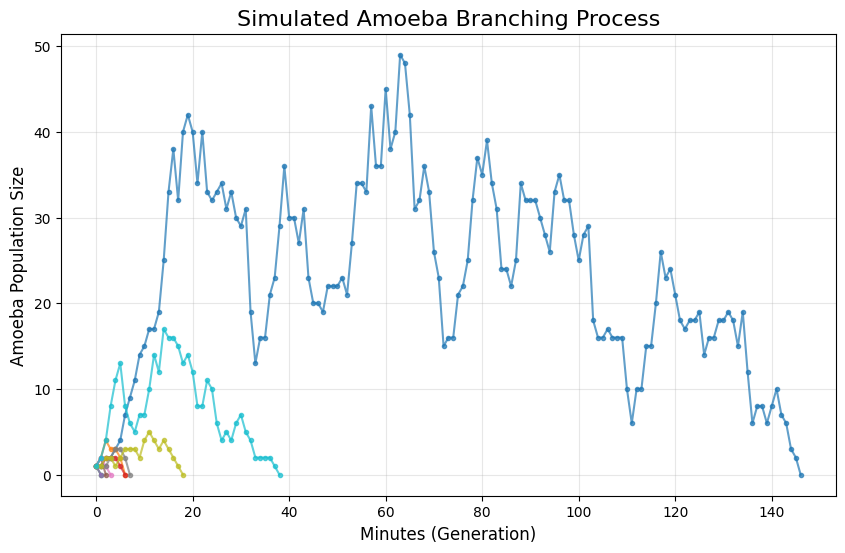

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_branching_process(p_probs=[1/3, 1/3, 1/3], max_gens=100):
    """
    Simulates a branching process where p_probs is a list of probabilities 
    for having [0, 1, 2] offspring.
    """
    population = 1
    history = [population]
    
    for _ in range(max_gens):
        if population == 0:
            break
            
        # For each living amoeba, draw their number of offspring (0, 1, or 2)
        # based on the provided probability distribution.
        next_generation = np.sum(np.random.choice([0, 1, 2], size=population, p=p_probs))
        population = next_generation
        history.append(population)
        
    return history

# Run several simulations
plt.figure(figsize=(10, 6))

for i in range(10):
    # Notice how some populations die immediately, while others might surge before eventually collapsing
    history = simulate_branching_process(max_gens=300)
    plt.plot(history, marker='o', markersize=3, alpha=0.7, label=f'Run {i+1}')

plt.title('Simulated Amoeba Branching Process', fontsize=16)
plt.xlabel('Minutes (Generation)', fontsize=12)
plt.ylabel('Amoeba Population Size', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()